In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step-1 : Data Cleaning

In [2]:
df = pd.read_csv("spam.csv",encoding="latin1")
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
369,ham,"Cool, text me when you're ready",NaN,NaN,NaN
4226,ham,Buy one egg for me da..please:),NaN,NaN,NaN
5150,ham,Happy new year to u and ur family...may this n...,NaN,NaN,NaN
5518,ham,"By the way, i've put a skip right outside the ...",NaN,NaN,NaN
4784,spam,Urgent -call 09066649731from Landline. Your co...,NaN,NaN,NaN


In [3]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [4]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [5]:
df.shape

(5572, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [7]:
# we need to remove the last three rows due to less non-null values

df.drop(columns=['Unnamed: 2','Unnamed: 3',"Unnamed: 4"],inplace=True)

In [8]:
df.sample(5)

,v1,v2
3988,ham,Ok lor. Anyway i thk we cant get tickets now c...
5263,ham,Pls speak with me. I wont ask anything other t...
4833,ham,I hope your pee burns tonite.
4587,ham,I wanted to wish you a Happy New Year and I wa...
3426,ham,Haha okay... Today weekend leh...


In [9]:
# renaming the feature name to make it sense
df.rename(columns={"v1":"target",'v2':"text"},inplace=True)
df.sample(5)

,target,text
4631,ham,"I'm in a meeting, call me later at"
2506,ham,Who u talking about?
1911,ham,Lol grr my mom is taking forever with my presc...
5366,spam,A å£400 XMAS REWARD IS WAITING FOR YOU! Our co...
3083,ham,Ok lor. I ned 2 go toa payoh 4 a while 2 retur...


### label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])

In [11]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# checking missing values 
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
# checking for duplicated values
df.duplicated().sum()

np.int64(403)

In [14]:
df = df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

### Step-2 Exploratory Data Analysis (EDA)

In [16]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

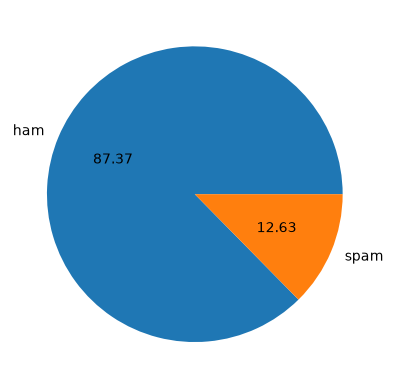

In [17]:
# Visualizing the spam distribution using pie-chart

plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [18]:
# Data is clearly imbalanced

### to classify on the basis of characters , words and sentences , we need to download the nltk library using pip install nltk

In [19]:
import nltk

In [20]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
# classify the lenght of each row respectively

df['sum_characters'] = df['text'].apply(len)

In [22]:
df.head()

,target,text,sum_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
# classifying on the basis of words on each row

df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [24]:
df.head(5)

,target,text,sum_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
# classifying on the basis of sentence using sen_tokenize()

# df['text'].apply(lambda x:nltk.sent_tokenize(x))
df['sent_sum'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [26]:
df

,target,text,sum_characters,num_words,sent_sum
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [27]:
df[['sum_characters','num_words','sent_sum']].describe()

,sum_characters,num_words,sent_sum
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
# description of ham message
df[df['target'] == 0 ][['sum_characters','num_words','sent_sum']].describe()

,sum_characters,num_words,sent_sum
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
df[df['target'] == 1][['sum_characters','num_words','sent_sum']].describe()

,sum_characters,num_words,sent_sum
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


### Visualizing the datasets using seaborn

<Axes: xlabel='sum_characters', ylabel='Count'>

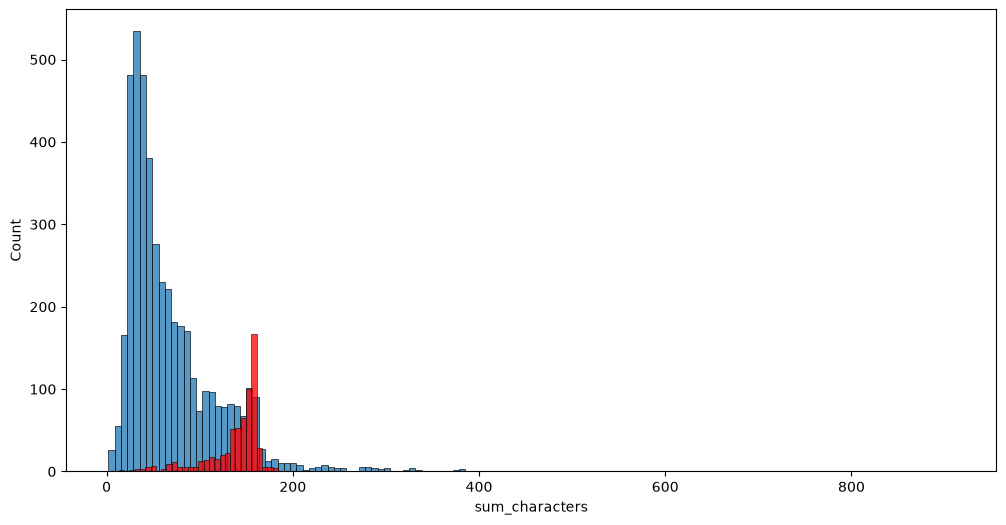

In [30]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['sum_characters'])
sns.histplot(df[df['target'] == 1]['sum_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

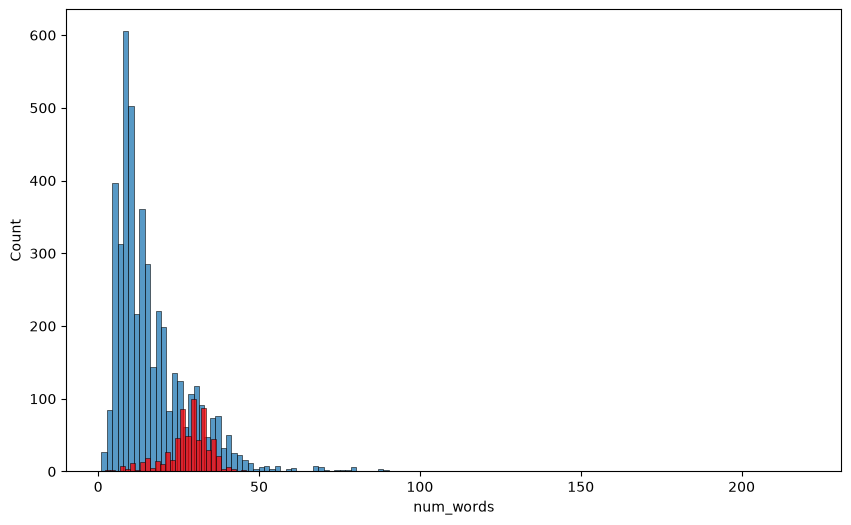

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'] , color='red')

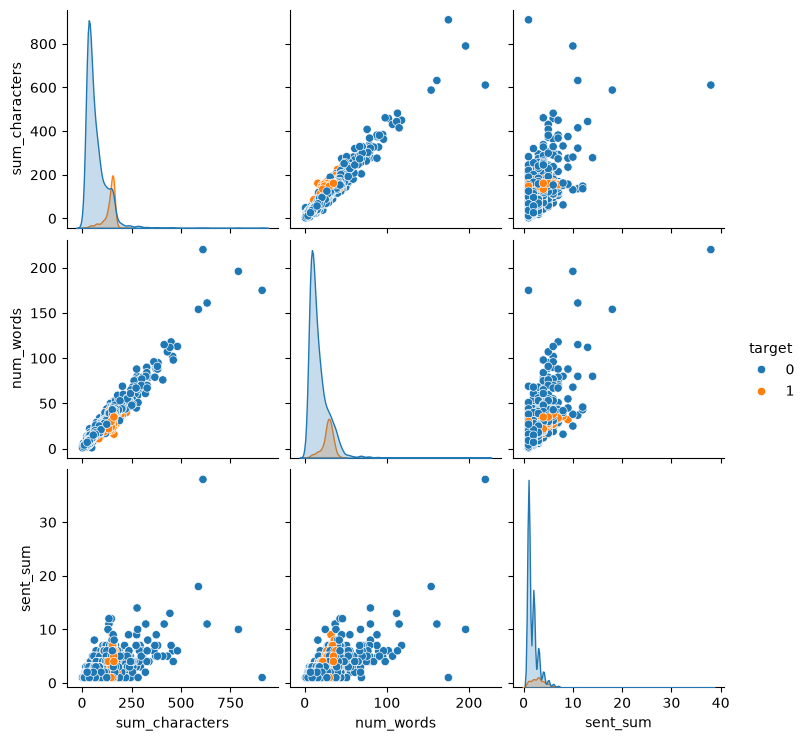

In [32]:
sns.pairplot(df,hue='target')

<Axes: >

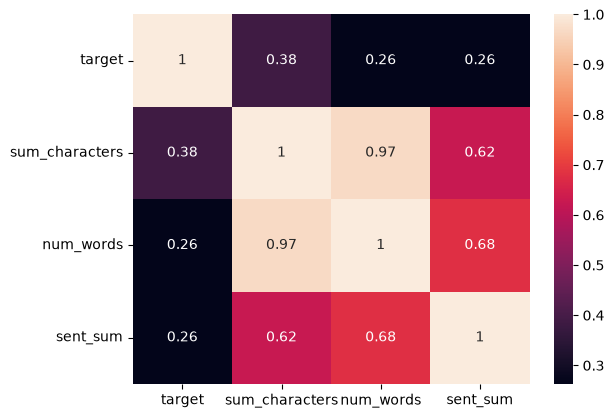

In [33]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

### Step-3 Data Preprocessing
 - Lower Case
 - Tokenization
 - Removing Special Characters
 - Removing Stop words and punctuation
 - Stemming

In [34]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    return text

In [35]:
transform_text("How are you?")

['how', 'are', 'you', '?']

In [36]:
df['text'][30]

"Wait that's still not all that clear, were you not sure about me being sarcastic or that that's why x doesn't want to live with us"

### This function removes only special characters

In [37]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    
    return y


In [38]:
transform_text(" Boom Boom $$$ ,Congrats!!,You have won $50 and get chance to win Iphone 17 pro max")

['boom',
 'boom',
 'congrats',
 'you',
 'have',
 'won',
 '50',
 'and',
 'get',
 'chance',
 'to',
 'win',
 'iphone',
 '17',
 'pro',
 'max']

In [39]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [40]:
## finding stopwords -> that is used to make sentence in english

from nltk.corpus import stopwords
stop_words = stopwords.words('english')
print(len(stop_words))  # Total number of English stopwords
print(stop_words[:20])  # first 20 stop words

198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [41]:
import string as str
str = str.punctuation
str

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [42]:
import string
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text) #Breaks the sentence into individual words and punctuation.

    y=[] #Creates an empty list.
    for i in text:
        if i.isalnum():#It checks whether the string contains only alphabets and numbers i.e no punctuation
            y.append(i) #Adds valid words into the list.

    text = y[:] #This copies the contents of y into text.
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not  in string.punctuation: # this removes stopwords and punctuation
            y.append(i) #Adds only useful words.

    return y
    

In [43]:
transform_text("Did you love machine learning ? \n How are you doing in Data Science?")

['love', 'machine', 'learning', 'data', 'science']

## Stemming

### Stemming is a text preprocessing technique in Natural Language Processing (NLP) that reduces a word to its root (stem) form by removing prefixes or suffixes.

 * The main goal is to treat different forms of the same word as a single word.
 * Notice that words like "studies", "studied", and "studying" all become "studi". Although "studi" is not a valid English word, it is good enough for many machine learning tasks because all these words are mapped to the same stem.

In [44]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem("loving")

'love'

In [45]:
import string
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text) #Breaks the sentence into individual words and punctuation.

    y=[] #Creates an empty list.
    for i in text:
        if i.isalnum():#It checks whether the string contains only alphabets and numbers i.e no punctuation
            y.append(i) #Adds valid words into the list.

    text = y[:] #This copies the contents of y into text.
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not  in string.punctuation: # this removes stopwords and punctuation
            y.append(i) #Adds only useful words.

    text = y[:]
    y.clear()

    # stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)
    

In [46]:
transform_text("I loved learning Machine learning through CampusX youtube channel.What about you?")

'love learn machin learn campusx youtub'

In [47]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [48]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...') # first row of datasets

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [49]:
df['text'].apply(transform_text)

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                                b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: text, Length: 5169, dtype: str

In [50]:
df['transformed_text'] = df['text'].apply(transform_text)

In [51]:
df.head(5)

,target,text,sum_characters,num_words,sent_sum,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [52]:
from wordcloud import WordCloud
wc = WordCloud(width=1000,height=1000,min_font_size=10,background_color='white')

In [53]:
spam_wc = wc.generate(df[df['target'] ==1 ]['transformed_text'].str.cat(sep=" "))

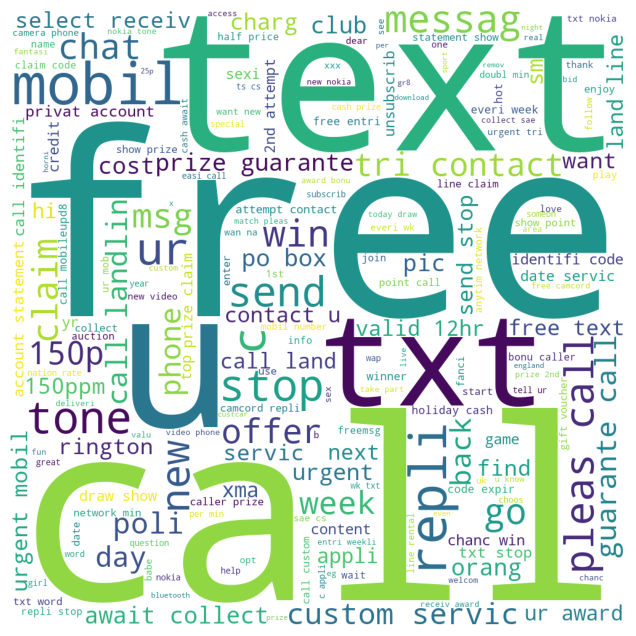

In [54]:
plt.figure(figsize=(8, 8))
plt.imshow(spam_wc)
plt.axis("off")   # Hide x and y axes
plt.show()

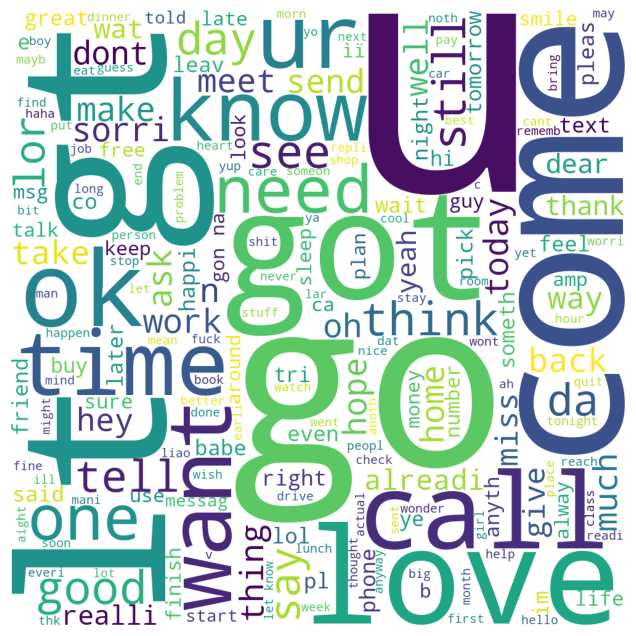

In [55]:
# visualizing for ham message

ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(8, 8))
plt.imshow(ham_wc)
plt.axis("off")   # Hide x and y axes
plt.show()

### getting top spam message 

In [56]:
spam_corpus =[]

for mssg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in mssg.split():
        spam_corpus.append(word)

In [57]:
len(spam_corpus)

9939

In [58]:
from collections import Counter

Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [59]:
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


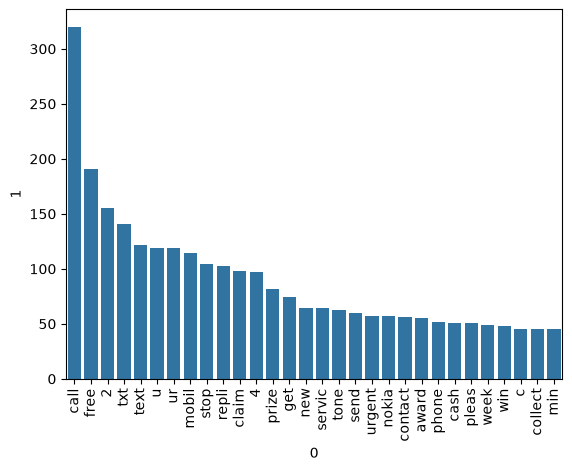

In [63]:
sns.barplot(
   x= pd.DataFrame(Counter(spam_corpus).most_common(30))[0],
   y= pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
)

plt.xticks(rotation=90)

plt.show()

In [64]:
ham_corpus=[]
for mssg in df[df['target']==0]['transformed_text'].tolist():
    for word in mssg.split():
        ham_corpus.append(word)

In [65]:
Counter(ham_corpus).most_common(30)

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234),
 ('call', 233),
 ('time', 219),
 ('ok', 217),
 ('love', 216),
 ('good', 213),
 ('want', 208),
 ('ur', 197),
 ('day', 190),
 ('need', 170),
 ('one', 165),
 ('lor', 159),
 ('4', 156),
 ('home', 152),
 ('think', 149),
 ('see', 147),
 ('take', 143),
 ('still', 143),
 ('da', 142),
 ('tell', 133),
 ('make', 129)]

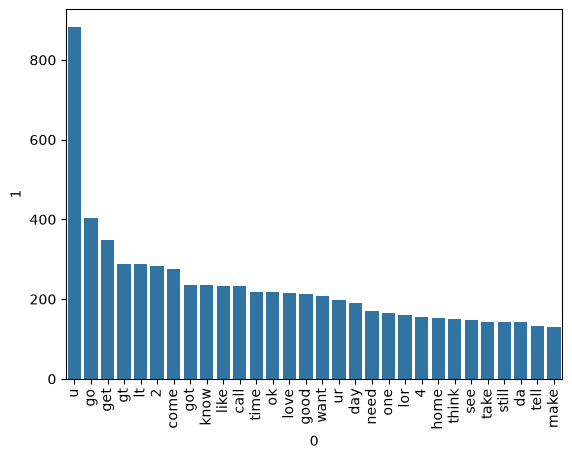

In [ ]:
x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0]
y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]

sns.barplot(
    x=x,
    y=y
)

plt.xticks(rotation=90)
plt.show()

### 4.Model Building

In [66]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

In [67]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [68]:

X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5169, 6708))

In [69]:
X.shape

(5169, 6708)

In [70]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Using Naive Bayes theorem


In [72]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

### Gaussian naive bayes

In [73]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,confusion_matrix

gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print("Accuracy Score:\t",accuracy_score(y_test,y_pred1))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred1))
print("Precision Score:\n",precision_score(y_test,y_pred1))

Accuracy Score:	 0.8684719535783365
Confusion Matrix:
 [[772 117]
 [ 19 126]]
Precision Score:
 0.5185185185185185


### Multinomial Naive bayes

In [74]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print("Accuracy Score:\t",accuracy_score(y_test,y_pred2))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred2))
print("Precision Score:\n",precision_score(y_test,y_pred2))

Accuracy Score:	 0.9738878143133463
Confusion Matrix:
 [[872  17]
 [ 10 135]]
Precision Score:
 0.8881578947368421


### Bernaulli naive bayes

In [ ]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print("Accuracy Score:\t",accuracy_score(y_test,y_pred3))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred3))
print("Precision Score:\n",precision_score(y_test,y_pred3))

Accuracy Score:	 0.9661508704061895
Confusion Matrix:
 [[885   4]
 [ 31 114]]
Precision Score:
 0.9661016949152542


In [76]:
from sklearn.feature_extraction.text import TfidfTransformer,CountVectorizer
cv = CountVectorizer()
tfidf = TfidfTransformer()


In [77]:
counts = cv.fit_transform(df['transformed_text'])

tfidf = TfidfTransformer()
X = tfidf.fit_transform(counts)

In [78]:
X=X.toarray()

In [79]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 6708))

In [80]:
y=df['target'].values

In [81]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Gaussian NB using tfidf

In [82]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,confusion_matrix

gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print("Accuracy Score:\t",accuracy_score(y_test,y_pred1))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred1))
print("Precision Score:\n",precision_score(y_test,y_pred1))

Accuracy Score:	 0.8636363636363636
Confusion Matrix:
 [[772 117]
 [ 24 121]]
Precision Score:
 0.5084033613445378


### Multinomial NB using tfidf

In [83]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print("Accuracy Score:\t",accuracy_score(y_test,y_pred2))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred2))
print("Precision Score:\n",precision_score(y_test,y_pred2))

Accuracy Score:	 0.9613152804642167
Confusion Matrix:
 [[888   1]
 [ 39 106]]
Precision Score:
 0.9906542056074766


### bernaulli NB using tfidf

In [84]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print("Accuracy Score:\t",accuracy_score(y_test,y_pred3))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred3))
print("Precision Score:\n",precision_score(y_test,y_pred3))

Accuracy Score:	 0.9661508704061895
Confusion Matrix:
 [[885   4]
 [ 31 114]]
Precision Score:
 0.9661016949152542


### Among these 3 naive bayes method ,multinomial NB gives better precision score .So , we use MNB by tfidf

In [85]:
## tfidf-->MNB(multinomial Naive Bayes)

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'